# Imports

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Loading the dataset

In [36]:

df = pd.read_csv('../data/dataset.csv')


# Basic cleaning, niose and duplicates

In [37]:
# Basic cleaning
df = df.replace(['?', ' ', ''], np.nan)   # convert weird values to NaN
df = df.drop_duplicates()                  # remove exact duplicate rows

# EDA

In [38]:

print(df.shape)
print(df.columns.tolist())
df.head()

(464, 14)
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1,0,125.0,212.0,0,1,168.0,0,1.0,2,2.0,3.0,0
1,53.0,1,0,140.0,203.0,1,0,155.0,1,3.1,0,0.0,3.0,0
2,70.0,1,0,145.0,174.0,0,1,125.0,1,2.6,0,0.0,3.0,0
3,61.0,1,0,148.0,203.0,0,1,161.0,0,0.0,2,1.0,3.0,0
4,62.0,0,0,138.0,294.0,1,1,106.0,0,1.9,1,NaN,NaN,0


In [39]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
Index: 464 entries, 0 to 1017
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       414 non-null    float64
 1   sex       464 non-null    int64  
 2   cp        464 non-null    int64  
 3   trestbps  417 non-null    float64
 4   chol      451 non-null    float64
 5   fbs       464 non-null    int64  
 6   restecg   464 non-null    int64  
 7   thalach   448 non-null    float64
 8   exang     464 non-null    int64  
 9   oldpeak   463 non-null    float64
 10  slope     464 non-null    int64  
 11  ca        413 non-null    float64
 12  thal      413 non-null    float64
 13  target    464 non-null    int64  
dtypes: float64(7), int64(7)
memory usage: 54.4 KB
None

Missing values:
 age         50
sex          0
cp           0
trestbps    47
chol        13
fbs          0
restecg      0
thalach     16
exang        0
oldpeak      1
slope        0
ca          51
thal        51
target       0
dt

In [40]:
print(df['target'].value_counts())

target
1    241
0    223
Name: count, dtype: int64


In [41]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  414.000000  464.000000  464.000000  417.000000  451.000000  464.000000   
mean    55.108696    0.661638    0.943966  132.729017  246.716186    0.157328   
std      8.999342    0.473663    1.023000   17.933932   51.207241    0.364502   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     49.000000    0.000000    0.000000  120.000000  211.500000    0.000000   
50%     56.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     62.000000    1.000000    2.000000  140.000000  277.000000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  464.000000  448.000000  464.000000  463.000000  464.000000  413.000000   
mean     0.558190  148.669643    0.368534    1.079482    1.379310    0.769976   
std      0.534812   22.8356

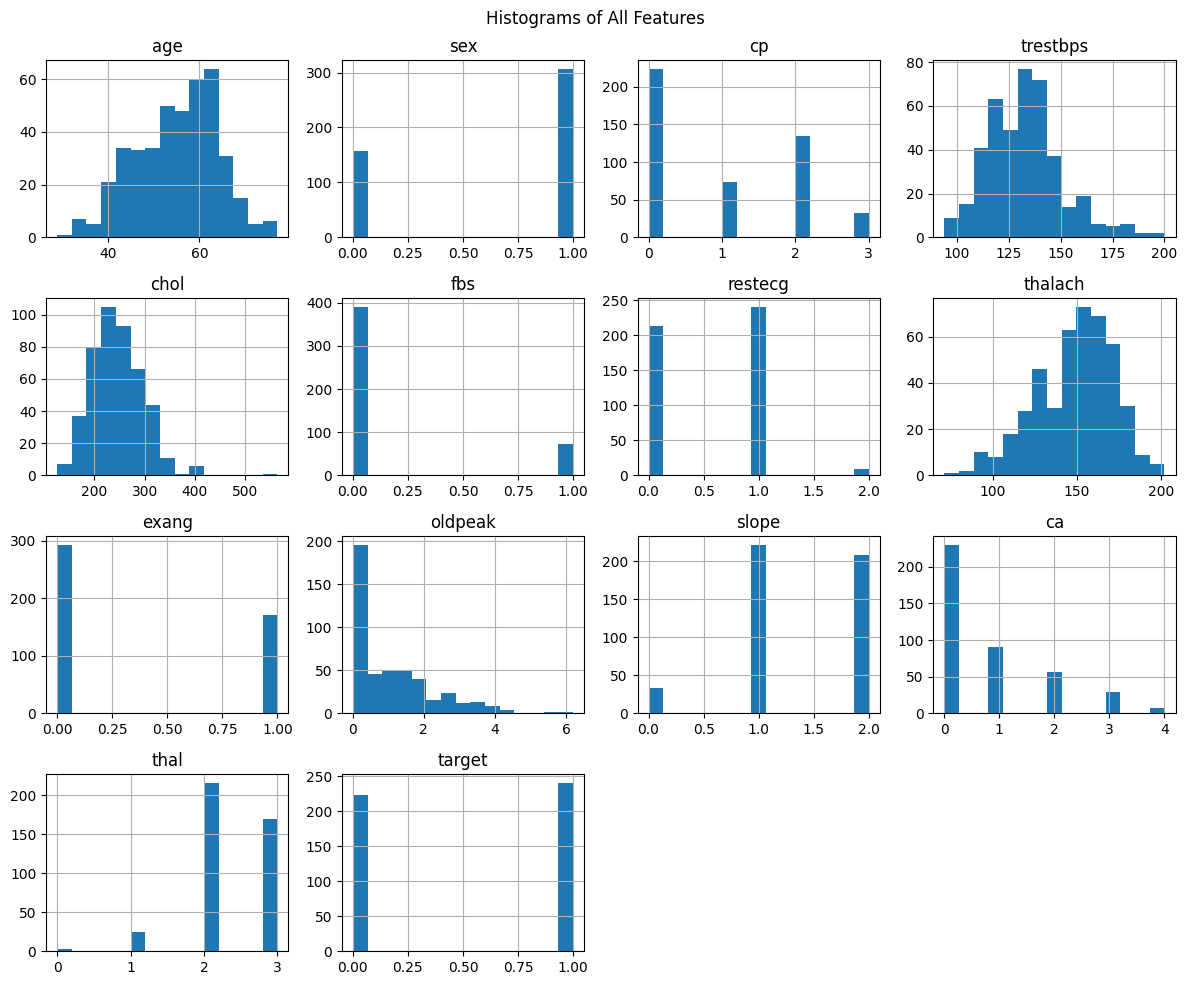

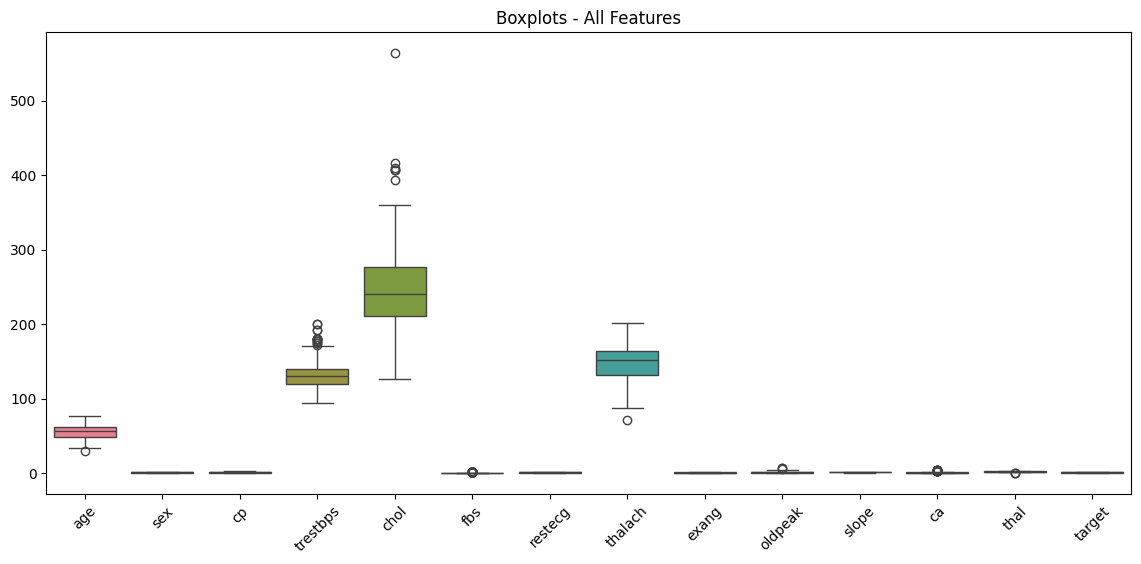

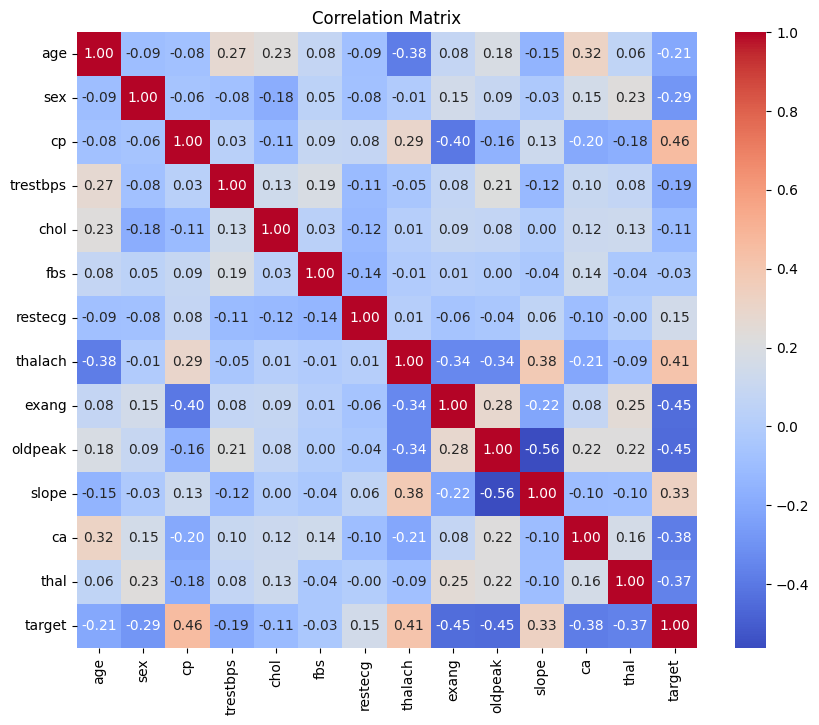

In [42]:

# 1. Histograms
df.hist(bins=15, figsize=(12, 10))
plt.suptitle("Histograms of All Features")
plt.tight_layout()
plt.show()

# 2. Boxplots - All features
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots - All Features")
plt.show()

# 3. Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


# Preprocessing

In [43]:
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [46]:
def preprocess_data(X_train, X_test, num_cols, cat_cols, numeric_impute_strategy='mean', numeric_scale_choice='zscore'):
    """
    Preprocess numeric and categorical data.

    Parameters:
    - numeric_impute_strategy: 'mean' or 'median' for numeric imputation
    - numeric_scale_choice: 'zscore', 'minmax', or 'robust' for numeric scaling
    """
    # Select scaler
    if numeric_scale_choice == 'zscore':
        scaler = StandardScaler()
    elif numeric_scale_choice == 'minmax':
        scaler = MinMaxScaler()
    elif numeric_scale_choice == 'robust':
        scaler = RobustScaler()

    # Numeric pipeline
    num_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy=numeric_impute_strategy)),
        ('scaler', scaler)
    ])

    # Categorical pipeline
    cat_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])

    # Column transformer
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)

    return X_train_transformed, X_test_transformed

# KNN

In [47]:
def train_knn(X_train, X_test, y_train, n_neighbors=5, metric='euclidean'):
    """
    Train KNN and return predictions.

    Parameters:
    - n_neighbors: number of neighbors (default 5)
    - metric: distance metric (default 'euclidean')
    """
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    return y_pred, knn

# Train & Test

In [51]:

impute_options = ['mean', 'median']
scale_options = ['zscore', 'minmax', 'robust']
k_values = [3, 5, 7, 9, 11]

for imp in impute_options:
    for scl in scale_options:
        # Preprocess
        X_train_proc, X_test_proc = preprocess_data(
            X_train, X_test, num_cols, cat_cols,
            numeric_impute_strategy=imp,
            numeric_scale_choice=scl
        )

        # Elbow plot: mean CV accuracy for each k
        cv_means = []
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
            scores = cross_val_score(knn, X_train_proc, y_train, cv=5, scoring='accuracy')
            cv_means.append(scores.mean())
        best_k = k_values[cv_means.index(max(cv_means))]

        # Train with best k
        knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
        knn.fit(X_train_proc, y_train)
        y_pred = knn.predict(X_test_proc)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        # Create figure
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"{imp.upper()} + {scl.upper()}  |  Best k={best_k}", fontsize=14, fontweight='bold')

        # Elbow plot
        axes[0].plot(k_values, cv_means, marker='o', color='steelblue')
        axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
        axes[0].set_xlabel('k (Neighbors)')
        axes[0].set_ylabel('CV Accuracy')
        axes[0].set_title('Elbow Plot')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Confusion matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Actual')
        axes[1].set_title('Confusion Matrix')

        # Metrics text
        metrics_text = f"Accuracy: {acc:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}  |  F1: {f1:.4f}"
        fig.text(0.5, 0.02, metrics_text, ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightgray'))
        
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])

        # Save
        filename = f"../results/figures/{imp}_{scl}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"Saved: {filename}  |  Best k={best_k}  |  Acc={acc:.4f}  F1={f1:.4f}")


Saved: ../results/figures/mean_zscore.png  |  Best k=3  |  Acc=0.8495  F1=0.8511
Saved: ../results/figures/mean_minmax.png  |  Best k=9  |  Acc=0.8172  F1=0.8247
Saved: ../results/figures/mean_robust.png  |  Best k=3  |  Acc=0.8710  F1=0.8723
Saved: ../results/figures/median_zscore.png  |  Best k=3  |  Acc=0.8602  F1=0.8632
Saved: ../results/figures/median_minmax.png  |  Best k=9  |  Acc=0.8280  F1=0.8333
Saved: ../results/figures/median_robust.png  |  Best k=3  |  Acc=0.8710  F1=0.8723
